### **Import**

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("gender_classification.csv")
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Shape: (5001, 8)
Missing values:
 long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64
Duplicates: 1768


### **Preproccessing**

In [2]:
# Select 4 features + target
df = df[["forehead_width_cm", "forehead_height_cm", "nose_wide", "nose_long", "gender"]]

# Remove duplicates
df = df.drop_duplicates()

# Encode target
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])  # Female=0, Male=1

# Features and target
X = df.drop("gender", axis=1)
y = df["gender"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1508, 4) | Test: (647, 4)


### **Test and Evaluate**

Accuracy: 0.848531684698609

              precision    recall  f1-score   support

      Female       0.84      0.79      0.82       273
        Male       0.85      0.89      0.87       374

    accuracy                           0.85       647
   macro avg       0.85      0.84      0.84       647
weighted avg       0.85      0.85      0.85       647



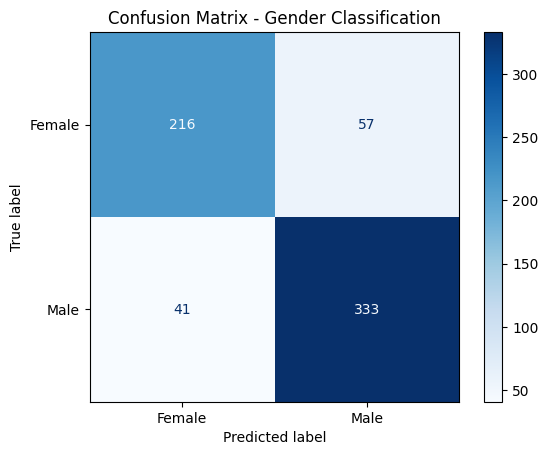

Predicted Gender: Male


In [3]:
# Train model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Female", "Male"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Gender Classification")
plt.show()

# External Prediction
new_data = [[13.5, 6.2, 1, 1]]
new_df = pd.DataFrame(new_data, columns=X.columns)
result = log_reg.predict(new_df)[0]
print("Predicted Gender:", le.inverse_transform([result])[0])